____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Surface

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5', ggd_var='adt', wd_depth='0'),
]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)

# Closure figs
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
df = df.reset_index().set_index('Pressure gradient')






nofilter__swot250naive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__L4noswotregional_adt__rio_0era5
nofilter__L4noswotglobal_adt__rio_0era5
nofilter__L4withswot_adt__rio_0era5
Identified SWOT and drifter outliers have been removed


147938
9.496911892467017
11.659318983023514
9.990449055942785
10.631601872624515
8.026736705503268
10.166957780875642
8.082899207951375
8.767029130152801
7.161963588249967
9.197160352717075
6.62125109502744
7.243279302391205
7.075146507248391
9.097409595185916
6.45717487279136
7.051962554558383
7.207044290649137
9.26720125308724
6.697670516497512
7.31678792192103


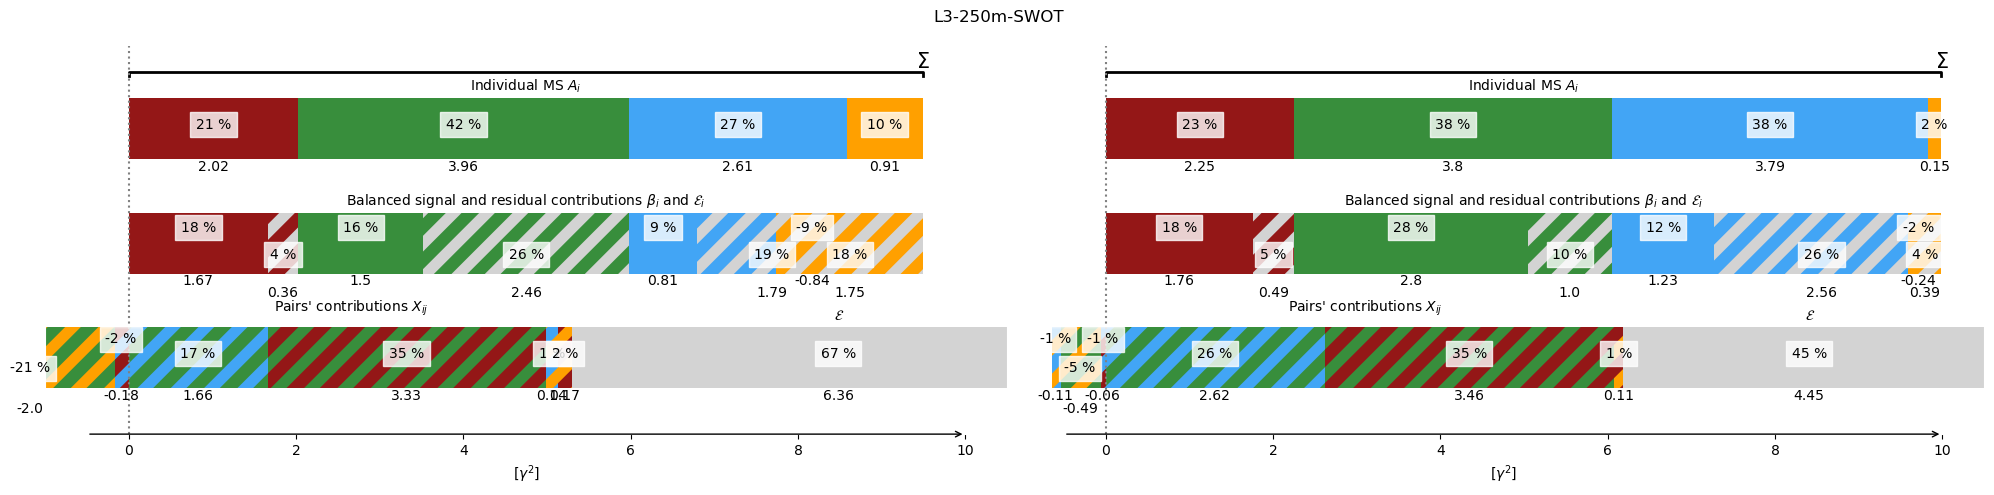

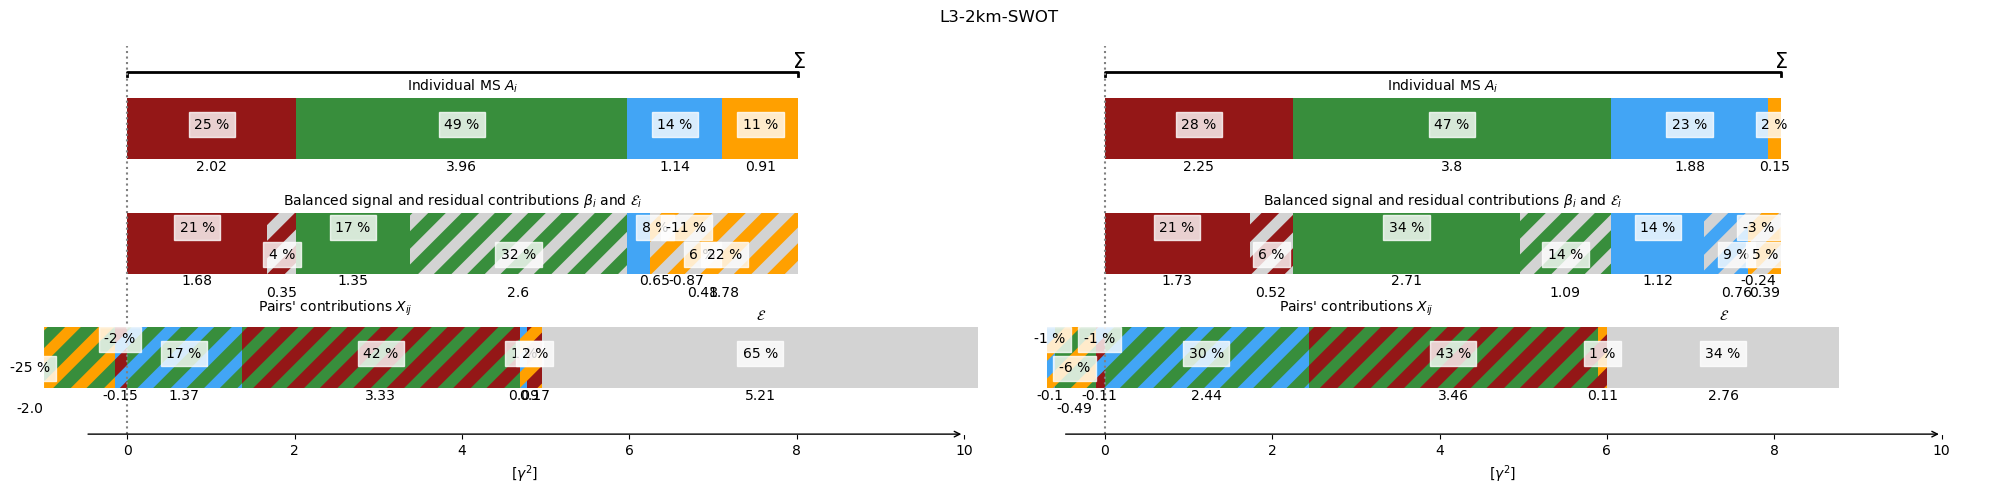

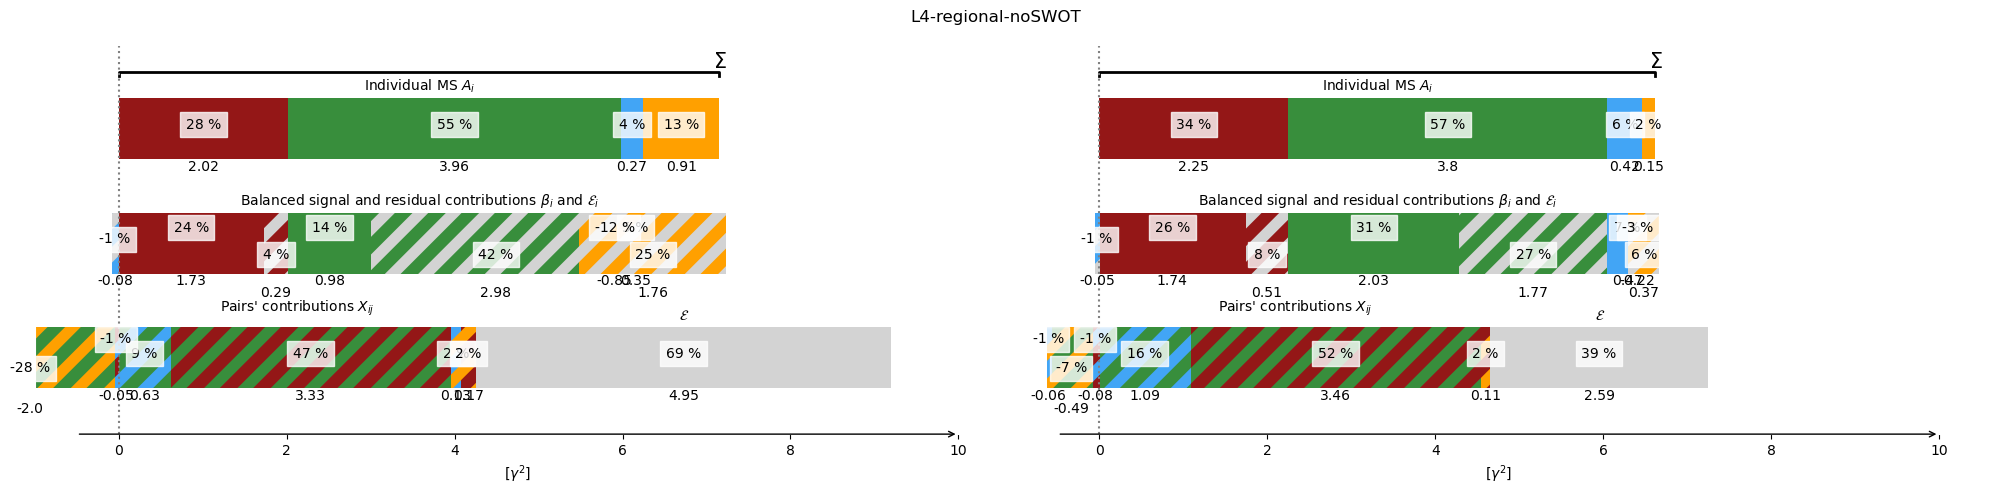

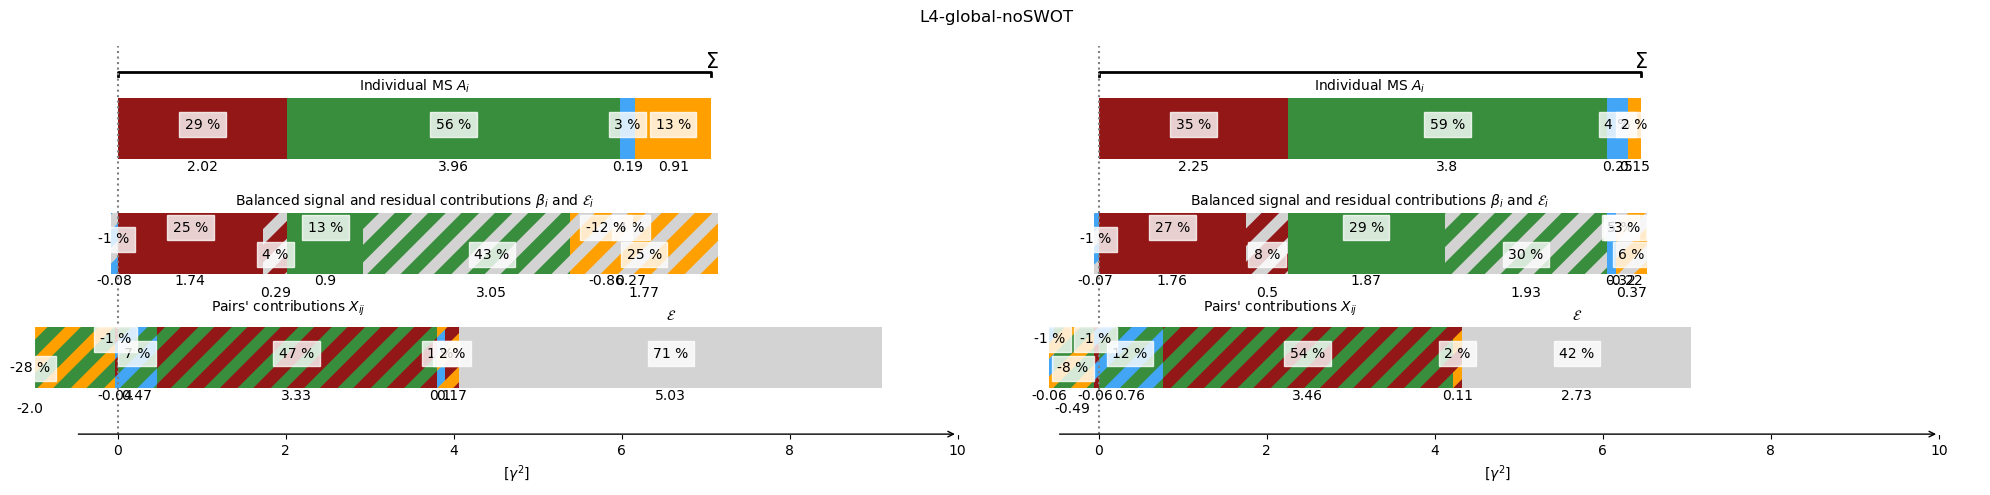

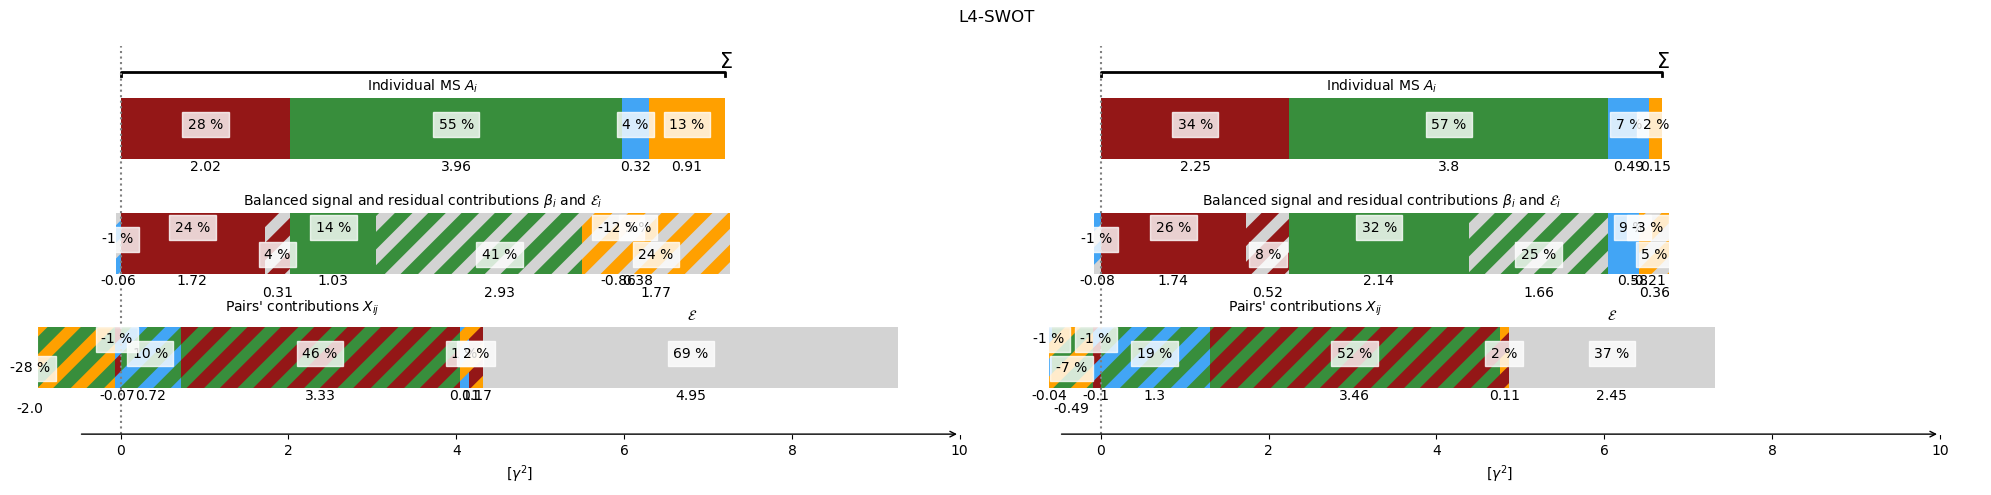

In [4]:
# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


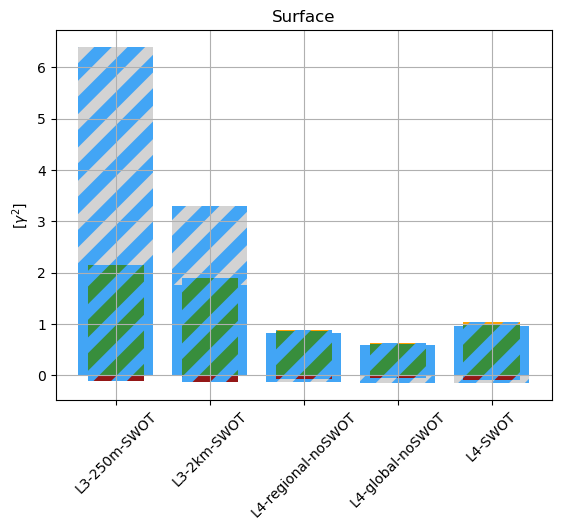

In [18]:
# Alti comparison
fig, ax = plt.subplots(frameon=False)
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 8
    plt.rcParams["hatch.color"] = "lightgrey"
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df.B_ggd,color = c0['ggd'], hatch="/")
    else: ax.bar(i, df_.E_ggd, color = c0['ggd'], hatch="/")
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
ax.set_title('Surface')
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd_' + c + '.png'))


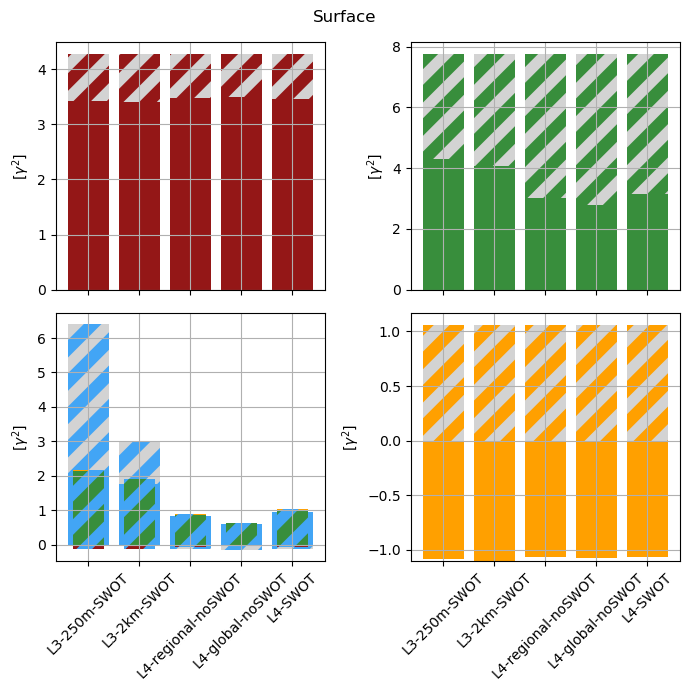

In [19]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
fig.suptitle('Surface')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all_' + c + '.png'))


# Depth =15m

In [8]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSD = DS.where(DS.depth==15, drop=True)


ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
df = df.reset_index().set_index('Pressure gradient')

nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
nofilter__L4noswotregional_adt__rio_15era5
nofilter__L4noswotglobal_adt__rio_15era5
nofilter__L4withswot_adt__rio_15era5
Identified SWOT and drifter outliers have been removed


5.853613642158059
6.300812055285512
7.106325885679414
7.524799993798729
4.820544871921339
5.278949373067946
5.885165190622785
6.287463193998627
4.0624746436547134
4.431702157836914
4.6595922159430385
5.008187312642643
3.95764365224236
4.3235080469603915
4.444166981214774
4.759258708239535
4.151017721177442
4.552296185257726
4.759096474906246
5.124004912536401


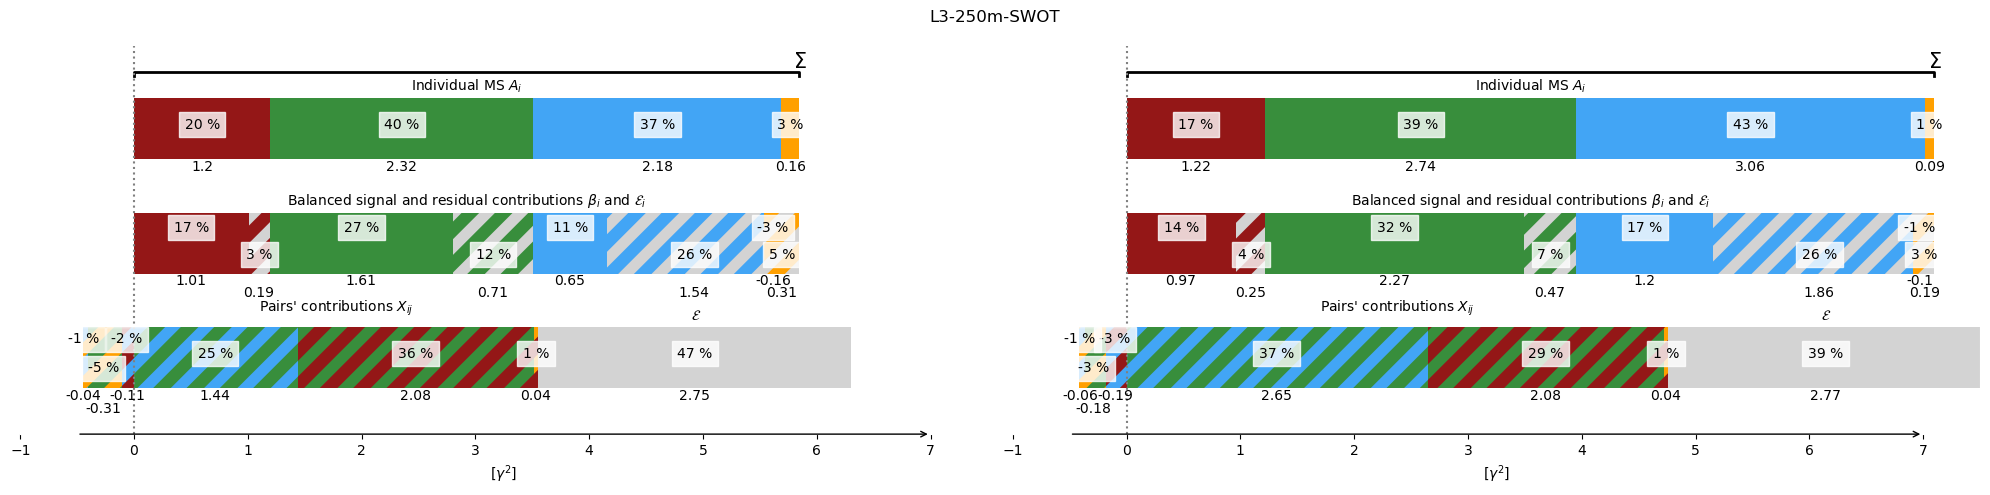

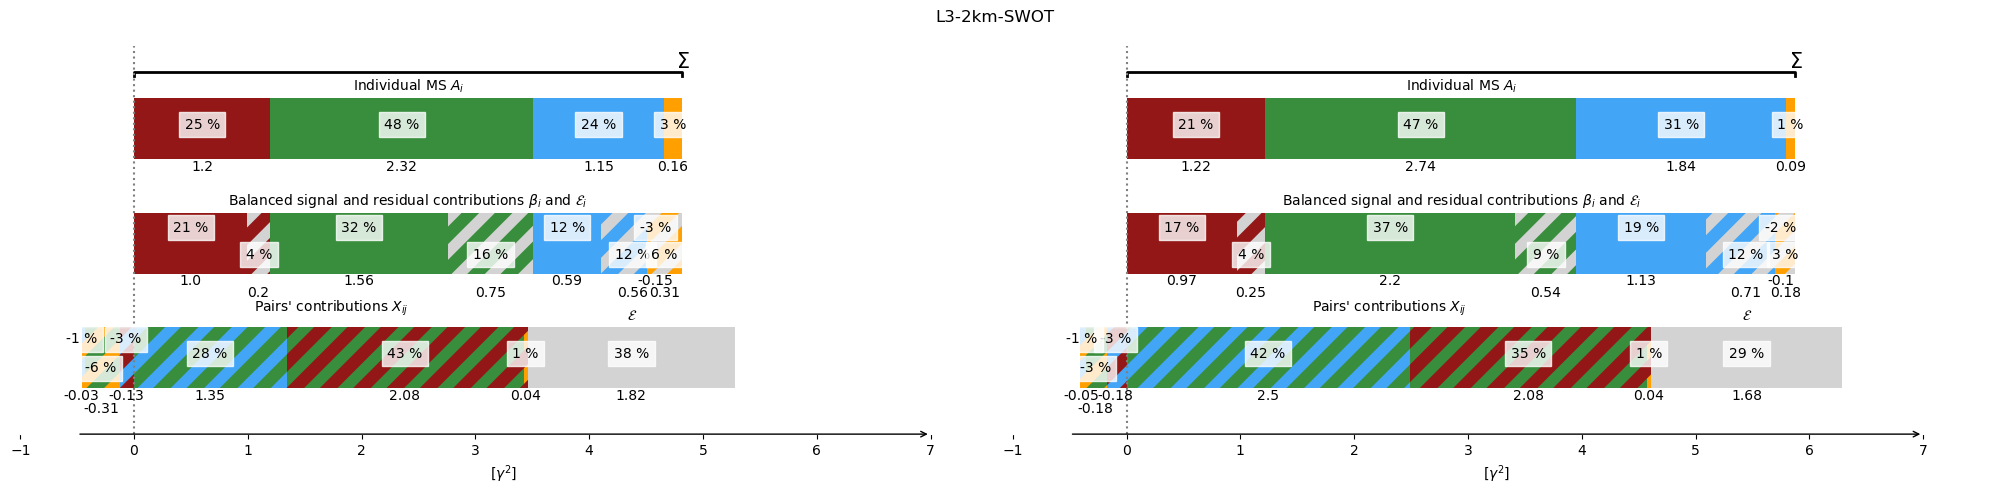

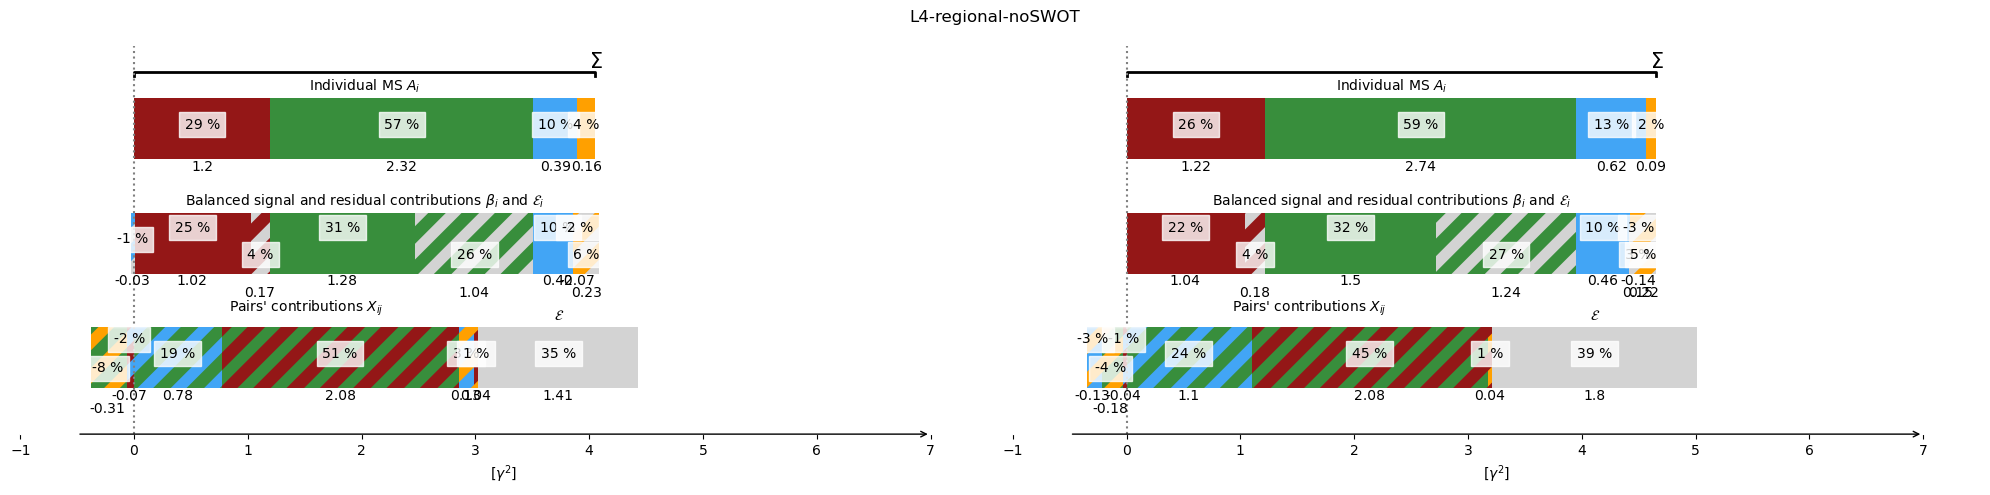

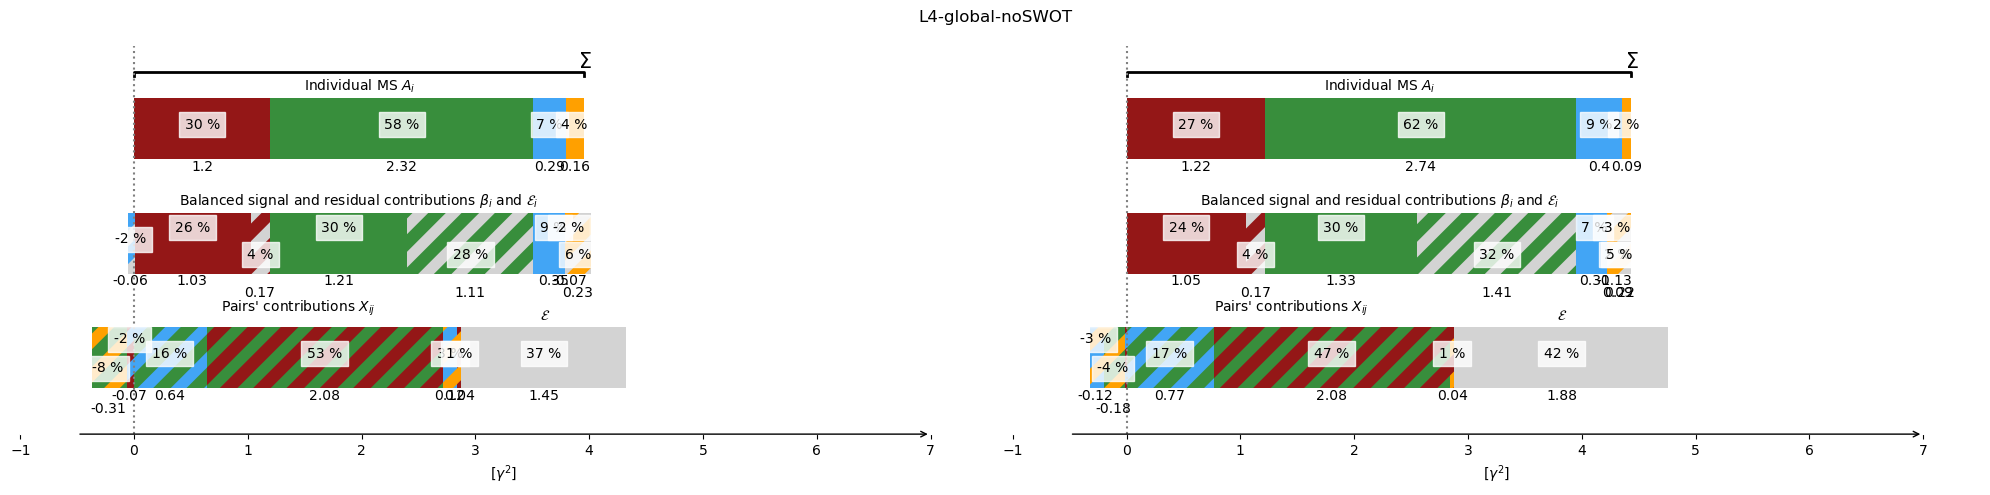

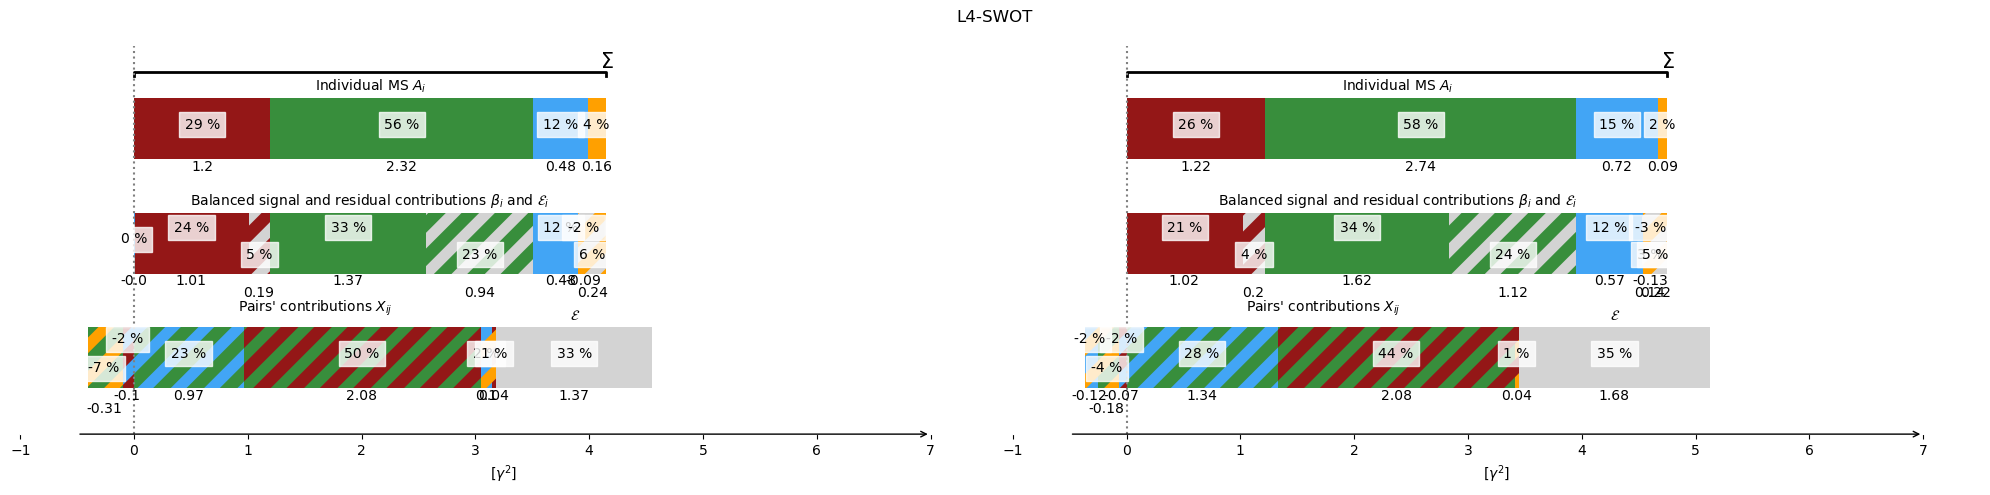

In [9]:
# Closure figs
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 7])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 7])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


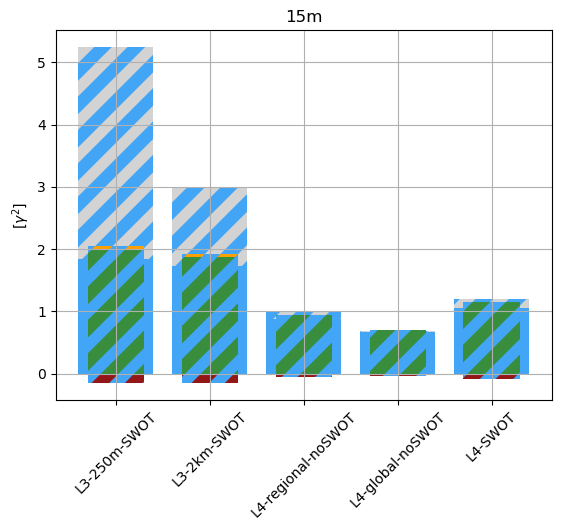

In [10]:
# Alti comparison
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(frameon=False)
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 8
    plt.rcParams["hatch.color"] = "lightgrey"
    if ['E_'+vars[j]]>0: ax.bar(i, ['E_'+vars[j]], bottom = df_.B_ggd,color = c0['ggd'], hatch="/")
    else: ax.bar(i, ['E_'+vars[j]], color = c0['ggd'], hatch="/")
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
ax.set_title('15m')
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_15m_' + c + '.png'))
